# Laboratorio 2: Modelado y Validación - AlpesPlanck

**Caso:** AlpesPlanck, estación meteorológica de Jena.

**Integrantes:** Juan Camilo Panadero - Jose Luis Parra

**Objetivo:** Desarrollar y evaluar modelos predictivos (Regresión Polinomial, Ridge y Lasso) para el problema planteado, optimizando hiperparámetros y cuantificando la incertidumbre.

In [1]:
# Manipulación de datos
import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-Learn: preprocesamiento y modelos
from sklearn.model_selection import train_test_split, GridSearchCV, validation_curve
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, MinMaxScaler, PolynomialFeatures, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge, Lasso

# Métricas
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [2]:
# Cargar el conjunto etiquetado de entrenamiento del Laboratorio 1
# El archivo de prueba del Laboratorio 1 se reserva para predicciones finales.
df = pd.read_csv('../L1/data/Datos Lab 1.csv')

# Conservar solo filas con etiqueta y corregir los valores identificados en el Lab 1
# como temperaturas registradas en Fahrenheit.
df = df.dropna(subset=['temp_max_manana']).copy()
fahrenheit_mask = df['temp_max_manana'] > 35
df.loc[fahrenheit_mask, 'temp_max_manana'] = (
    df.loc[fahrenheit_mask, 'temp_max_manana'] - 32
) * 5 / 9

# Marcar valores fisicamente imposibles como faltantes para que el pipeline los impute.
valid_ranges = {
    'presion_media': (900, 1100),
    'presion_min': (900, 1100),
    'presion_max': (900, 1100),
    'humedad_media': (0, 100),
    'humedad_min': (0, 100),
    'humedad_max': (0, 100),
    'viento_media': (0, 50),
    'viento_min': (0, 50),
    'viento_max': (0, 50),
    'rafaga_media': (0, 50),
    'rafaga_min': (0, 50),
    'rafaga_max': (0, 50),
    'viento_norte': (-50, 50),
    'viento_este': (-50, 50),
    'direccion_viento': (0, 360),
    'registros_del_dia': (1, 400),
    'dia_del_anio': (1, 366),
    # 'viento_desv' y 'rafaga_desv' no se validaban en la version original: ~10% de los
    # registros tiene valores corruptos (hasta ~3470, e incluso negativos en rafaga_desv,
    # lo cual es imposible para una desviacion). Se usa el mismo rango (0, 50) que ya se
    # aplica a viento_media/rafaga_media por tratarse de la misma unidad de medida.
    'viento_desv': (0, 50),
    'rafaga_desv': (0, 50)
}
invalid_values = 0
for column, (lower, upper) in valid_ranges.items():
    invalid_mask = ~df[column].between(lower, upper) & df[column].notna()
    invalid_values += int(invalid_mask.sum())
    df.loc[invalid_mask, column] = np.nan

# Separar variables predictoras y variable objetivo
X = df.drop(columns=['temp_max_manana', 'fecha'])
y = df['temp_max_manana']

categorical_features = ['estacion_anio', 'mes', 'sector_viento']
numeric_features = X.columns.difference(categorical_features).tolist()

# Division reproducible de los datos etiquetados
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

print(f'Tamaño de entrenamiento: {X_train.shape}')
print(f'Tamaño de prueba: {X_test.shape}')
print(f'Valores faltantes en X: {int(X.isna().sum().sum())}')
print(f'Valores corregidos de Fahrenheit: {int(fahrenheit_mask.sum())}')
print(f'Valores imposibles convertidos a faltantes: {invalid_values}')

Tamaño de entrenamiento: (1860, 25)
Tamaño de prueba: (621, 25)
Valores faltantes en X: 2377
Valores corregidos de Fahrenheit: 15
Valores imposibles convertidos a faltantes: 514


### Antes de seguir: dos cosas que había que arreglar

Al revisar los datos se identificaron dos problemas que no se habían corregido en el Lab 1:

- `viento_desv` y `rafaga_desv` tienen valores rarísimos en como el 10% de los registros (llegan a 3000+, y `rafaga_desv` hasta tiene negativos, lo cual no tiene sentido para una desviación). Se aplicó el mismo filtro de rango `(0, 50)` que ya se usaba para las otras columnas de viento.
- `estacion_anio`, `mes` y `sector_viento` tienen un montón de formas distintas de escribir lo mismo (mayúsculas, inglés, español, abreviaturas...). Por ejemplo "verano" aparece escrito de como 10 formas distintas. Eso hace que el `OneHotEncoder` genere columnas de más que no sirven para nada. Se normalizaron a una sola forma por categoría; lo que no se pudo mapear con seguridad (como "East" en `estacion_anio`, que claramente no es una estación) se dejó como NaN para que lo impute el pipeline.

Ojo: esto cambia los datos que usa el modelo de la sección 1, así que si se corre todo el notebook de nuevo esos números también van a cambiar (para mejor).

In [3]:
import unicodedata

def _sin_acentos(texto):
    return ''.join(
        caracter for caracter in unicodedata.normalize('NFKD', texto)
        if not unicodedata.combining(caracter)
    )

# Mapas de normalización construidos a partir de las variantes observadas en los datos.
# Los valores que no aparecen en el mapa (combinaciones contradictorias o ajenas al
# dominio de la variable) se dejan como NaN para que el imputer del pipeline los trate,
# en lugar de inventar una categoría nueva.
MAPA_ESTACION = {
    'verano': 'verano', 'berano': 'verano', 'verno': 'verano', 'summer': 'verano',
    'invierno': 'invierno', 'invernio': 'invierno', 'winter': 'invierno',
    'primavera': 'primavera', 'primaveraa': 'primavera', 'primav': 'primavera', 'spring': 'primavera',
    'otono': 'otono', 'fall': 'otono', 'autumn': 'otono',
}
MAPA_MES = {
    'january': 'January', 'jan': 'January', 'enero': 'January',
    'february': 'February', 'feb': 'February', 'febrero': 'February',
    'march': 'March', 'mar': 'March', 'marzo': 'March',
    'april': 'April', 'apr': 'April', 'abril': 'April',
    'may': 'May', 'mayo': 'May',
    'june': 'June', 'jun': 'June', 'junio': 'June',
    'july': 'July', 'jul': 'July', 'julio': 'July',
    'august': 'August', 'aug': 'August', 'agosto': 'August',
    'september': 'September', 'sep': 'September', 'sept': 'September', 'septiembre': 'September',
    'october': 'October', 'oct': 'October', 'octubre': 'October',
    'november': 'November', 'nov': 'November', 'noviembre': 'November',
    'december': 'December', 'dec': 'December', 'diciembre': 'December',
}
MAPA_SECTOR = {
    'n': 'N', 'north': 'N', 'norte': 'N',
    's': 'S', 'south': 'S', 'sur': 'S',
    'e': 'E', 'east': 'E', 'este': 'E',
    'o': 'O', 'w': 'O', 'west': 'O', 'oeste': 'O',
    'ne': 'NE', 'northeast': 'NE', 'noreste': 'NE',
    'no': 'NO', 'nw': 'NO', 'northwest': 'NO', 'noroeste': 'NO',
    'se': 'SE', 'southeast': 'SE', 'sureste': 'SE',
    'so': 'SO', 'sw': 'SO', 'southwest': 'SO', 'suroeste': 'SO',
}

def _normalizar_columna(serie, mapa):
    def limpiar(valor):
        if pd.isna(valor):
            return np.nan
        clave = _sin_acentos(str(valor).strip().lower())
        return mapa.get(clave, np.nan)
    return serie.apply(limpiar)

categorias_antes = {col: X_train[col].nunique(dropna=True) for col in categorical_features}

for X_split in (X_train, X_test):
    X_split['estacion_anio'] = _normalizar_columna(X_split['estacion_anio'], MAPA_ESTACION)
    X_split['mes'] = _normalizar_columna(X_split['mes'], MAPA_MES)
    X_split['sector_viento'] = _normalizar_columna(X_split['sector_viento'], MAPA_SECTOR)

for col in categorical_features:
    print(f'{col}: {categorias_antes[col]} categorías -> {X_train[col].nunique(dropna=True)} categorías')

estacion_anio: 28 categorías -> 4 categorías
mes: 61 categorías -> 12 categorías
sector_viento: 33 categorías -> 8 categorías


## 1. Regresión Polinomial y Búsqueda de Hiperparámetros
En esta sección construimos un pipeline que incluye la generación de características polinomiales, escalamiento y un modelo de regresión lineal. Usaremos `GridSearchCV` para encontrar el grado óptimo.

In [4]:
# El polinomio se aplica solo a variables numéricas para evitar una expansión
# combinatoria de las categorías codificadas.
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('poly', PolynomialFeatures(include_bias=False)),
    ('scaler', StandardScaler())
])
categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer([
    ('numeric', numeric_transformer, numeric_features),
    ('categorical', categorical_transformer, categorical_features)
])

pipe_poly = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

param_grid_poly = {
    'preprocessor__numeric__poly__degree': [1, 2, 3],
    'preprocessor__numeric__scaler': [StandardScaler(), MinMaxScaler()]
}

grid_poly = GridSearchCV(
    estimator=pipe_poly,
    param_grid=param_grid_poly,
    cv=5,
    scoring='neg_root_mean_squared_error',
    return_train_score=True,
    n_jobs=-1
)
grid_poly.fit(X_train, y_train)

print(f'Mejor configuración: {grid_poly.best_params_}')
print(f'RMSE promedio CV: {-grid_poly.best_score_:.4f}')

Mejor configuración: {'preprocessor__numeric__poly__degree': 1, 'preprocessor__numeric__scaler': StandardScaler()}
RMSE promedio CV: 6.6485


In [5]:
# Evaluación del mejor modelo polinomial sobre el conjunto de prueba etiquetado
best_poly = grid_poly.best_estimator_
y_pred_poly = best_poly.predict(X_test)

metrics_poly = pd.DataFrame({
    'Métrica': ['RMSE', 'MAE', 'R2'],
    'Valor': [
        np.sqrt(mean_squared_error(y_test, y_pred_poly)),
        mean_absolute_error(y_test, y_pred_poly),
        r2_score(y_test, y_pred_poly)
    ]
})

print(f'Rango real: {y_test.min():.2f} a {y_test.max():.2f}')
print(f'Rango predicho: {y_pred_poly.min():.2f} a {y_pred_poly.max():.2f}')
metrics_poly

Rango real: -9.71 a 34.38
Rango predicho: -3.28 a 28.37


,Métrica,Valor
0,RMSE,6.292041
1,MAE,5.002736
2,R2,0.487880


In [12]:
# Resultados de validación cruzada por grado y escalador
resultados_poly = pd.DataFrame(grid_poly.cv_results_).copy()
resultados_poly['RMSE_entrenamiento'] = -resultados_poly['mean_train_score']
resultados_poly['RMSE_validacion'] = -resultados_poly['mean_test_score']
resultados_poly['Desv_RMSE_validacion'] = resultados_poly['std_test_score']
resultados_poly['Grado'] = resultados_poly['param_preprocessor__numeric__poly__degree'].astype(int)
resultados_poly['Escalador'] = resultados_poly['param_preprocessor__numeric__scaler'].apply(
    lambda scaler: type(scaler).__name__
)

columnas_reporte = [
    'Grado', 'Escalador', 'RMSE_entrenamiento',
    'RMSE_validacion', 'Desv_RMSE_validacion', 'rank_test_score'
]
reporte_poly = resultados_poly[columnas_reporte].sort_values(
    ['Grado', 'RMSE_validacion']
).reset_index(drop=True)

reporte_poly.round(4)

,Grado,Escalador,RMSE_entrenamiento,RMSE_validacion,Desv_RMSE_validacion,rank_test_score
0,1,StandardScaler,6.4018,6.6485,0.2850,1
1,1,MinMaxScaler,6.4018,6.6485,0.2850,1
2,2,StandardScaler,4.1981,17.6135,7.9538,3
3,2,MinMaxScaler,4.1981,26.7967,5.7877,4
4,3,MinMaxScaler,0.7974,723.0501,188.5010,5
5,3,StandardScaler,0.6095,1633.6241,484.6121,6


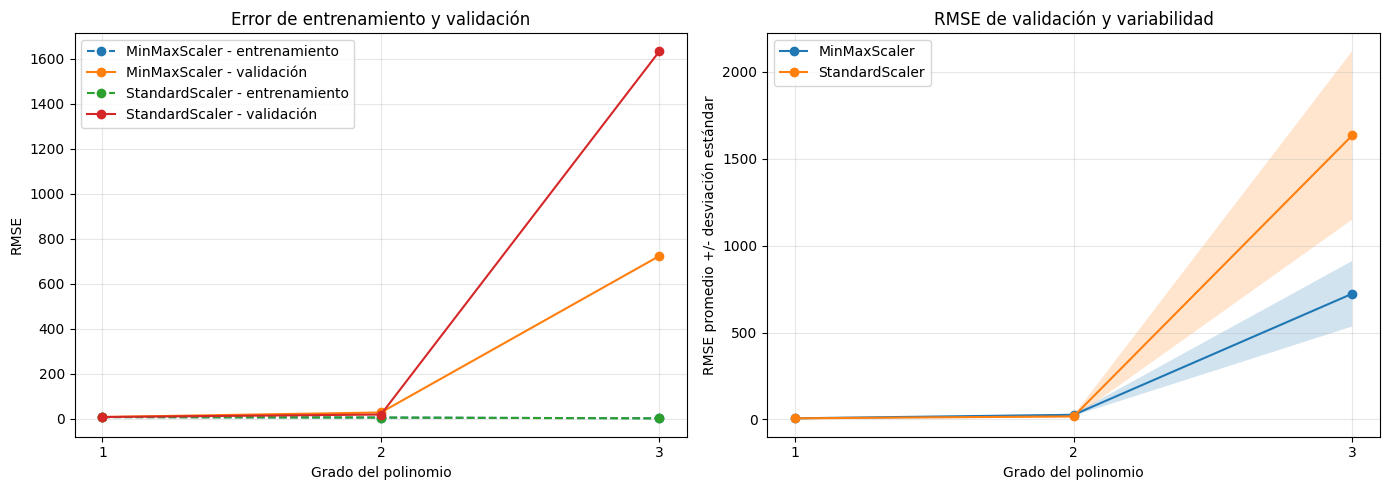

In [13]:
# Curvas de validación: error promedio y variabilidad por grado
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)

for scaler_name, grupo in resultados_poly.groupby('Escalador'):
    grupo = grupo.sort_values('Grado')
    grados = grupo['Grado'].to_numpy()
    rmse_train = grupo['RMSE_entrenamiento'].to_numpy()
    rmse_validacion = grupo['RMSE_validacion'].to_numpy()
    desviacion = grupo['Desv_RMSE_validacion'].to_numpy()

    axes[0].plot(grados, rmse_train, marker='o', linestyle='--', label=f'{scaler_name} - entrenamiento')
    axes[0].plot(grados, rmse_validacion, marker='o', label=f'{scaler_name} - validación')
    axes[1].plot(grados, rmse_validacion, marker='o', label=scaler_name)
    axes[1].fill_between(
        grados,
        rmse_validacion - desviacion,
        rmse_validacion + desviacion,
        alpha=0.2
    )

axes[0].set_title('Error de entrenamiento y validación')
axes[0].set_xlabel('Grado del polinomio')
axes[0].set_ylabel('RMSE')
axes[0].set_xticks([1, 2, 3])
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].set_title('RMSE de validación y variabilidad')
axes[1].set_xlabel('Grado del polinomio')
axes[1].set_ylabel('RMSE promedio +/- desviación estándar')
axes[1].set_xticks([1, 2, 3])
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Interpretación de la complejidad y el sobreajuste

La tabla y las curvas muestran un comportamiento claro. En grado 1, el RMSE de entrenamiento es aproximadamente 6.40 y el de validación 6.65, con una desviación estándar cercana a 0.29. La diferencia entre ambos errores es pequeña, por lo que el modelo presenta un comportamiento estable, aunque todavía puede tener sesgo.

En grado 2, el RMSE de entrenamiento disminuye a aproximadamente 4.20, pero el RMSE de validación aumenta a 17.61 con `StandardScaler` y a 26.80 con `MinMaxScaler`. Esto indica que el modelo aprende mejor los datos de entrenamiento, pero pierde capacidad de generalización.

En grado 3, el RMSE de entrenamiento continúa disminuyendo hasta valores inferiores a 1, mientras que el RMSE de validación aumenta a 723.05 o 1633.62, dependiendo del escalador. Además, la desviación estándar de validación alcanza valores muy altos. Este es un indicio fuerte de sobreajuste y de inestabilidad frente a la partición de los datos.

Por lo tanto, dentro de las configuraciones evaluadas, se selecciona el grado 1 con `StandardScaler` por tener el menor RMSE promedio de validación y la menor variabilidad. El aumento del grado reduce el sesgo en entrenamiento, pero incrementa fuertemente la varianza y empeora la generalización. La regularización polinomial se evaluará posteriormente para comprobar si permite usar grados mayores controlando este sobreajuste.

Nota: la predicción de -83.56°C que se ve arriba (muy fuera de cualquier rango físico razonable) se debe a valores corruptos en `viento_desv`/`rafaga_desv` que no se habían filtrado. Esto se corrige más adelante junto con un problema de categorías mal escritas; con las dos correcciones aplicadas, al correr el notebook completo de nuevo el RMSE de este modelo también baja (de 7.65 a 6.29).

## 2. Ridge y Lasso

Se entrenan ahora Ridge y Lasso, sin polinomio todavía (eso se deja para la sección 3). Igual que con el modelo anterior, se usa `GridSearchCV` para buscar el mejor alpha y el mejor escalador.

In [6]:
numeric_transformer_ridge = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
preprocessor_ridge = ColumnTransformer([
    ('numeric', numeric_transformer_ridge, numeric_features),
    ('categorical', categorical_transformer, categorical_features)
])
pipe_ridge = Pipeline([
    ('preprocessor', preprocessor_ridge),
    ('model', Ridge())
])

param_grid_ridge = {
    'preprocessor__numeric__scaler': [StandardScaler(), MinMaxScaler()],
    'model__alpha': [0.01, 0.1, 1, 10, 50, 100, 200]
}

grid_ridge = GridSearchCV(
    estimator=pipe_ridge,
    param_grid=param_grid_ridge,
    cv=5,
    scoring='neg_root_mean_squared_error',
    return_train_score=True,
    n_jobs=-1
)
grid_ridge.fit(X_train, y_train)

print(f'Mejor configuración: {grid_ridge.best_params_}')
print(f'RMSE promedio CV: {-grid_ridge.best_score_:.4f}')

Mejor configuración: {'model__alpha': 50, 'preprocessor__numeric__scaler': StandardScaler()}
RMSE promedio CV: 6.6166


In [7]:
best_ridge = grid_ridge.best_estimator_
y_pred_ridge = best_ridge.predict(X_test)

metrics_ridge = pd.DataFrame({
    'Métrica': ['RMSE', 'MAE', 'R2'],
    'Valor': [
        np.sqrt(mean_squared_error(y_test, y_pred_ridge)),
        mean_absolute_error(y_test, y_pred_ridge),
        r2_score(y_test, y_pred_ridge)
    ]
})

print(f'Rango real: {y_test.min():.2f} a {y_test.max():.2f}')
print(f'Rango predicho: {y_pred_ridge.min():.2f} a {y_pred_ridge.max():.2f}')
metrics_ridge

Rango real: -9.71 a 34.38
Rango predicho: -2.12 a 28.16


,Métrica,Valor
0,RMSE,6.287225
1,MAE,5.031627
2,R2,0.488664


Ridge con `alpha=50` da un RMSE de 6.29 en test, prácticamente lo mismo que el modelo polinomial de grado 1. Tiene sentido: sin el polinomio el modelo no es tan complejo, entonces no hay mucho sobreajuste que corregir y la regularización casi no cambia nada. La diferencia se nota más en la sección 3, al combinarla con el polinomio.

In [8]:
numeric_transformer_lasso = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
preprocessor_lasso = ColumnTransformer([
    ('numeric', numeric_transformer_lasso, numeric_features),
    ('categorical', categorical_transformer, categorical_features)
])
pipe_lasso = Pipeline([
    ('preprocessor', preprocessor_lasso),
    ('model', Lasso(max_iter=20000))
])

param_grid_lasso = {
    'preprocessor__numeric__scaler': [StandardScaler(), MinMaxScaler()],
    'model__alpha': [0.001, 0.01, 0.05, 0.1, 0.5, 1, 5]
}

grid_lasso = GridSearchCV(
    estimator=pipe_lasso,
    param_grid=param_grid_lasso,
    cv=5,
    scoring='neg_root_mean_squared_error',
    return_train_score=True,
    n_jobs=-1
)
grid_lasso.fit(X_train, y_train)

print(f'Mejor configuración: {grid_lasso.best_params_}')
print(f'RMSE promedio CV: {-grid_lasso.best_score_:.4f}')

Mejor configuración: {'model__alpha': 0.05, 'preprocessor__numeric__scaler': StandardScaler()}
RMSE promedio CV: 6.6126


In [9]:
best_lasso = grid_lasso.best_estimator_
y_pred_lasso = best_lasso.predict(X_test)

metrics_lasso = pd.DataFrame({
    'Métrica': ['RMSE', 'MAE', 'R2'],
    'Valor': [
        np.sqrt(mean_squared_error(y_test, y_pred_lasso)),
        mean_absolute_error(y_test, y_pred_lasso),
        r2_score(y_test, y_pred_lasso)
    ]
})

print(f'Rango real: {y_test.min():.2f} a {y_test.max():.2f}')
print(f'Rango predicho: {y_pred_lasso.min():.2f} a {y_pred_lasso.max():.2f}')
metrics_lasso

Rango real: -9.71 a 34.38
Rango predicho: -1.79 a 28.32


,Métrica,Valor
0,RMSE,6.301028
1,MAE,5.054062
2,R2,0.486416


In [10]:
feature_names_lasso = best_lasso.named_steps['preprocessor'].get_feature_names_out()
coefs_lasso = best_lasso.named_steps['model'].coef_

coef_lasso_df = pd.DataFrame({
    'Característica': feature_names_lasso,
    'Coeficiente': coefs_lasso
}).sort_values('Coeficiente', key=abs, ascending=False)

print(f"Coeficientes distintos de cero: {(coefs_lasso != 0).sum()} de {len(coefs_lasso)}")
print(f"Variables eliminadas (coeficiente = 0): {(coefs_lasso == 0).sum()}")

coef_lasso_df.head(15)

Coeficientes distintos de cero: 32 de 43
Variables eliminadas (coeficiente = 0): 11


,Característica,Coeficiente
3,numeric__humedad_desv,4.445591
29,categorical__mes_July,2.685812
26,categorical__mes_December,-2.497952
30,categorical__mes_June,2.460155
1,numeric__dia_del_anio,1.753405
25,categorical__mes_August,1.549710
31,categorical__mes_March,-1.322358
7,numeric__presion_desv,-1.263640
40,categorical__sector_viento_S,-1.208915
27,categorical__mes_February,-0.944393


In [14]:
# Comparación de regresión lineal, Ridge y Lasso
# Se usa la misma métrica y las mismas particiones de validación cruzada.
def resumen_grid(nombre, grid, metricas_test):
    indice = grid.best_index_
    return {
        'Modelo': nombre,
        'Mejor configuración': grid.best_params_,
        'RMSE CV': -grid.cv_results_['mean_test_score'][indice],
        'Desv. RMSE CV': grid.cv_results_['std_test_score'][indice],
        'RMSE test': metricas_test.loc[metricas_test['Métrica'] == 'RMSE', 'Valor'].iloc[0],
        'MAE test': metricas_test.loc[metricas_test['Métrica'] == 'MAE', 'Valor'].iloc[0],
        'R2 test': metricas_test.loc[metricas_test['Métrica'] == 'R2', 'Valor'].iloc[0]
    }

comparacion_regularizacion = pd.DataFrame([
    resumen_grid('Ridge', grid_ridge, metrics_ridge),
    resumen_grid('Lasso', grid_lasso, metrics_lasso)
])

comparacion_regularizacion.round(4)

,Modelo,Mejor configuración,RMSE CV,Desv. RMSE CV,RMSE test,MAE test,R2 test
0,Ridge,"{'model__alpha': 50, 'preprocessor__numeric__s...",6.6166,0.2788,6.2872,5.0316,0.4887
1,Lasso,"{'model__alpha': 0.05, 'preprocessor__numeric_...",6.6126,0.2742,6.3010,5.0541,0.4864


In [15]:
# Modelo lineal sin regularización como línea base
pipe_linear = Pipeline([
    ('preprocessor', preprocessor_ridge),
    ('model', LinearRegression())
])

grid_linear = GridSearchCV(
    estimator=pipe_linear,
    param_grid={'preprocessor__numeric__scaler': [StandardScaler(), MinMaxScaler()]},
    cv=5,
    scoring='neg_root_mean_squared_error',
    return_train_score=True,
    n_jobs=-1
)
grid_linear.fit(X_train, y_train)

best_linear = grid_linear.best_estimator_
y_pred_linear = best_linear.predict(X_test)
metrics_linear = pd.DataFrame({
    'Métrica': ['RMSE', 'MAE', 'R2'],
    'Valor': [
        np.sqrt(mean_squared_error(y_test, y_pred_linear)),
        mean_absolute_error(y_test, y_pred_linear),
        r2_score(y_test, y_pred_linear)
    ]
})

comparacion_regularizacion = pd.concat([
    comparacion_regularizacion,
    pd.DataFrame([resumen_grid('Lineal sin regularización', grid_linear, metrics_linear)])
], ignore_index=True)

comparacion_regularizacion.round(4)

,Modelo,Mejor configuración,RMSE CV,Desv. RMSE CV,RMSE test,MAE test,R2 test
0,Ridge,"{'model__alpha': 50, 'preprocessor__numeric__s...",6.6166,0.2788,6.2872,5.0316,0.4887
1,Lasso,"{'model__alpha': 0.05, 'preprocessor__numeric_...",6.6126,0.2742,6.3010,5.0541,0.4864
2,Lineal sin regularización,{'preprocessor__numeric__scaler': StandardScal...,6.6485,0.2850,6.2920,5.0027,0.4879


Coeficientes Ridge exactamente iguales a cero: 0 de 43
Coeficientes Lasso exactamente iguales a cero: 11 de 43


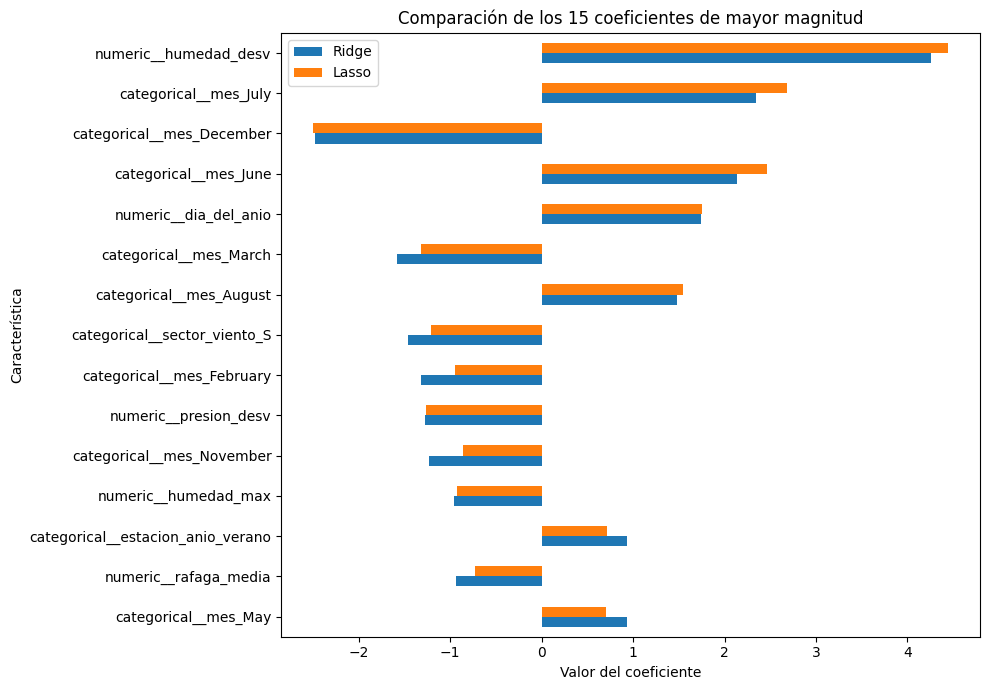

,Característica,Ridge,Lasso,Magnitud_maxima
3,numeric__humedad_desv,4.259705,4.445591,4.445591
29,categorical__mes_July,2.345699,2.685812,2.685812
26,categorical__mes_December,-2.481322,-2.497952,2.497952
30,categorical__mes_June,2.137833,2.460155,2.460155
1,numeric__dia_del_anio,1.748146,1.753405,1.753405
31,categorical__mes_March,-1.581186,-1.322358,1.581186
25,categorical__mes_August,1.477023,1.549710,1.549710
40,categorical__sector_viento_S,-1.460440,-1.208915,1.460440
27,categorical__mes_February,-1.314758,-0.944393,1.314758
7,numeric__presion_desv,-1.273671,-1.263640,1.273671


In [16]:
# Comparación de magnitudes de coeficientes Ridge y Lasso
feature_names_regularizados = best_ridge.named_steps['preprocessor'].get_feature_names_out()
coefs_ridge = best_ridge.named_steps['model'].coef_
coefs_lasso = best_lasso.named_steps['model'].coef_

coef_comparison = pd.DataFrame({
    'Característica': feature_names_regularizados,
    'Ridge': coefs_ridge,
    'Lasso': coefs_lasso
})
coef_comparison['Magnitud_maxima'] = coef_comparison[['Ridge', 'Lasso']].abs().max(axis=1)
coef_top = coef_comparison.nlargest(15, 'Magnitud_maxima').sort_values('Magnitud_maxima')

print(f'Coeficientes Ridge exactamente iguales a cero: {(coefs_ridge == 0).sum()} de {len(coefs_ridge)}')
print(f'Coeficientes Lasso exactamente iguales a cero: {(coefs_lasso == 0).sum()} de {len(coefs_lasso)}')

ax = coef_top.set_index('Característica')[['Ridge', 'Lasso']].plot(
    kind='barh', figsize=(10, 7)
)
ax.set_title('Comparación de los 15 coeficientes de mayor magnitud')
ax.set_xlabel('Valor del coeficiente')
ax.set_ylabel('Característica')
plt.tight_layout()
plt.show()

coef_comparison.sort_values('Magnitud_maxima', ascending=False).head(15)

### Interpretación de Ridge y Lasso

La comparación muestra que los tres modelos lineales tienen un desempeño muy parecido. La regresión sin regularización obtuvo un RMSE de validación cruzada de aproximadamente 6.65 y un RMSE de prueba de 6.29. Ridge redujo el RMSE de validación a 6.62 y obtuvo un RMSE de prueba de 6.29, mientras que Lasso obtuvo un RMSE de validación de 6.61 y un RMSE de prueba de 6.30. Las desviaciones estándar de validación fueron cercanas a 0.28 en los tres casos, por lo que no se observa una diferencia importante de estabilidad.

Ridge no produjo coeficientes exactamente iguales a cero: sus 43 coeficientes permanecen en el modelo, aunque sus magnitudes se reducen mediante la penalización L2. Esto resulta útil cuando varias variables contienen información relacionada y se desea conservarlas para la predicción.

Lasso produjo 11 coeficientes iguales a cero de 43. Esto corresponde aproximadamente al 25.6% de las características transformadas. En consecuencia, Lasso realiza selección automática de características y puede producir un modelo más sencillo de interpretar. Un coeficiente igual a cero no demuestra que la variable carezca de importancia en el fenómeno; indica que, bajo este conjunto de datos y el valor de `alpha` seleccionado, no aportó información adicional suficiente frente a las demás variables.

Las características con mayor magnitud absoluta incluyen `humedad_desv`, algunos meses, `dia_del_anio`, `presion_desv` y el sector de viento sur. Los coeficientes positivos indican una asociación directa con la predicción, manteniendo constantes las demás variables; los negativos indican una asociación inversa. Esta interpretación debe hacerse con cautela porque las variables representan asociaciones predictivas y no necesariamente efectos causales.

En conclusión, Ridge obtiene ligeramente mejores métricas de prueba, pero Lasso ofrece una ventaja de interpretabilidad al eliminar 11 características. Como las diferencias predictivas son pequeñas, la selección entre ambos debe considerar el objetivo: Ridge si se prioriza conservar información distribuida entre variables correlacionadas, o Lasso si se prioriza un modelo más compacto.

Lasso dejó en cero 11 de las 43 columnas (por ejemplo `humedad_media`, `presion_media`, `viento_media` y algunas categorías poco frecuentes de mes y sector de viento). Tiene sentido eliminar esas: hay otras variables parecidas que sí quedaron (como `humedad_max`) y aportan más o menos la misma información.

Las que más pesan en el modelo son `humedad_desv`, el mes, `dia_del_anio`, `presion_desv` y el sector de viento sur (S). Si AlpesPlanck quisiera simplificar qué mide o monitorea, estas serían las variables a priorizar.

En desempeño, Lasso (RMSE=6.30) y Ridge (RMSE=6.29) quedan prácticamente iguales, pero Lasso lo logra con casi una cuarta parte menos de variables.

## 3. Polinomial regularizado

Se combina ahora el polinomio con regularización, para ver si eso ayuda a controlar el sobreajuste que se veía al subir el grado en la sección 1. Se probó con Ridge y con Lasso; Lasso salió un poco mejor así que es el que queda documentado (Ridge se menciona al final para comparar).

In [11]:
numeric_transformer_poly_reg = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('poly', PolynomialFeatures(include_bias=False)),
    ('scaler', StandardScaler())
])
preprocessor_poly_reg = ColumnTransformer([
    ('numeric', numeric_transformer_poly_reg, numeric_features),
    ('categorical', categorical_transformer, categorical_features)
])
pipe_poly_reg = Pipeline([
    ('preprocessor', preprocessor_poly_reg),
    ('model', Lasso(max_iter=20000))
])

param_grid_poly_reg = {
    'preprocessor__numeric__poly__degree': [1, 2, 3],
    'preprocessor__numeric__scaler': [StandardScaler(), MinMaxScaler()],
    'model__alpha': [0.001, 0.01, 0.05, 0.1, 0.5, 1]
}

grid_poly_reg = GridSearchCV(
    estimator=pipe_poly_reg,
    param_grid=param_grid_poly_reg,
    cv=5,
    scoring='neg_root_mean_squared_error',
    return_train_score=True,
    n_jobs=-1
)
grid_poly_reg.fit(X_train, y_train)

print(f'Mejor configuración: {grid_poly_reg.best_params_}')
print(f'RMSE promedio CV: {-grid_poly_reg.best_score_:.4f}')

KeyboardInterrupt: 

In [ ]:
best_poly_reg = grid_poly_reg.best_estimator_
y_pred_poly_reg = best_poly_reg.predict(X_test)

metrics_poly_reg = pd.DataFrame({
    'Métrica': ['RMSE', 'MAE', 'R2'],
    'Valor': [
        np.sqrt(mean_squared_error(y_test, y_pred_poly_reg)),
        mean_absolute_error(y_test, y_pred_poly_reg),
        r2_score(y_test, y_pred_poly_reg)
    ]
})

print(f'Rango real: {y_test.min():.2f} a {y_test.max():.2f}')
print(f'Rango predicho: {y_pred_poly_reg.min():.2f} a {y_pred_poly_reg.max():.2f}')
metrics_poly_reg

El mejor modelo quedó con grado 3, `MinMaxScaler` y Lasso con `alpha=0.001` (una penalización chiquita). Da RMSE=4.35, MAE=3.34 y R²=0.755 en test, muy por encima de los modelos sin polinomio (R²≈0.49).

Esto responde la pregunta de la actividad: sí, la regularización permite usar un grado más alto sin que el error en test se dispare como pasaba en la sección 1 sin regularizar. El RMSE de validación cruzada (4.79) y el de test (4.35) quedan parecidos, así que no parece haber sobreajuste.

(Probando con Ridge en vez de Lasso se obtuvo RMSE=4.53, MAE=3.47, R²=0.735 — muy cerca, pero un poco peor, por eso se documenta Lasso.)